In [1]:
# # Dask 2024.2.1 seems to be the latest version where spatial_partitions work with dask-geopandas 0.3.1
# # Note that dask 2023.12.0 also does not work anymore with dask-geopandas 0.3.1
# # Thus we very specifically need the following versions:

# dask==2024.2.1
# dask-geopandas==0.3.1

# https://github.com/geopandas/dask-geopandas/issues/287

In [2]:
# # To downgrade do the following:

# pip uninstall dask-geopandas
# pip uninstall distributed
# pip uninstall dask-exp
# pip uninstall dask[dataframe]
# pip install dask==2024.2.1
# pip install -U --no-deps dask-geopandas
# pip install -U --no-deps distributed

# BTW: When tryin to do
# pip install -U --no-deps dask-exp
# it fails with error message:
# ERROR: Could not find a version that satisfies the requirement dask-exp (from versions: none)
# ERROR: No matching distribution found for dask-exp

In [3]:
# # THIS MAY BE RELATED TO THIS ISSUE:
# # https://github.com/geopandas/dask-geopandas/issues/284

# The 2024.2.0 release of Dask has deprecated the "legacy" dask.dataframe API. They are building a new API with "Query Planning" based on new high-level expressions (instead of the current HighLevelGraph), which currently lives in the dask-expr package.
# It can be enabled through dask.config.set({'dataframe.query-planning': True}).

# The upcoming 2024.3.0 release (dask/community#366) plans to enable this by default (but you can still turn it off for now).

# Given that dask-geopandas is tightly integrated with dask.dataframe, we will have to update to use the new dask_expr backend.
# For released versions of dask-geopandas, users will have to upper pin dask or disable the option for now.

# (for reference, a similar issue on the cudf side rapidsai/cudf#15027 (they also have a subclass), and their PR to add basic support: rapidsai/cudf#14805)

In [4]:
pip freeze | grep dask

dask==2024.2.1
dask-geopandas==0.3.1
Note: you may need to restart the kernel to use updated packages.


In [5]:
%%time
import geodatasets
import tempfile
import dask_geopandas
import geopandas

CPU times: total: 78.1 ms
Wall time: 2.7 s


In [6]:
%%time
df = geopandas.read_file(geodatasets.get_url("geoda airbnb"))
ddf = dask_geopandas.from_geopandas(df, npartitions=4).spatial_shuffle()
ddf.to_parquet("tmp/out.parquet")
dask_geopandas.read_parquet("tmp/out.parquet").spatial_partitions

CPU times: total: 156 ms
Wall time: 3.89 s


0    POLYGON ((-87.63396 41.77113, -87.63396 42.018...
1    POLYGON ((-87.59852 41.82361, -87.59852 42.023...
2    POLYGON ((-87.54060 41.73678, -87.54060 41.890...
3    POLYGON ((-87.52414 41.64454, -87.52414 41.794...
dtype: geometry

<Axes: >

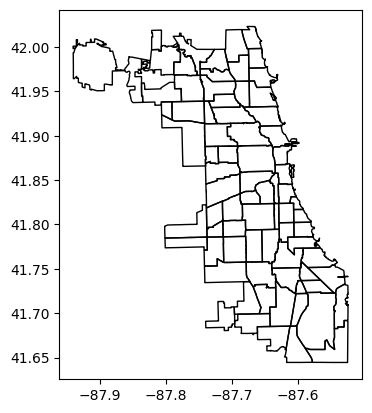

In [7]:
gdf = ddf.compute().reset_index(drop=True)
gdf.plot(color='none')